## Notebook for plotting priors and likelihoods of Pliocene, Eocene and Cretaceous case studies

Author: **N.J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [ ]:
# Load data needed for plots

# Pliocene data
PlioMIP
mu_prior_SAT_monthly
std_prior_SAT_monthly
mu_prior_SST_monthly
std_prior_SST_monthly
mu_prior_precip_monthly
std_prior_precip_monthly
mu_prior_SSS_monthly
std_prior_SSS_monthly
mu_likelihood_monthly_aggregated
PWP_var_start_d18Oc_monthly = var_names.index("Final_d18O") * num_bins_monthly # Determine the start index for the d18Oc variable
PWP_var_end_d18Oc_monthly = PWP_var_start_d18Oc_monthly + num_bins_monthly # Determine the end index for the d18Oc variable
PWP_n_update_monthly_aggregated_d18Oc = n_update_monthly_aggregated[PWP_var_start_d18Oc_monthly:PWP_var_end_d18Oc_monthly]  # Extract the number of updates for d18Oc
PWP_var_start_D47_monthly = var_names.index("D47_corrETF_strict") * num_bins_monthly # Determine the start index for the D47 variable
PWP_var_end_D47_monthly = PWP_var_start_D47_monthly + num_bins_monthly # Determine the end index for the D47 variable
PWP_n_update_monthly_aggregated_D47 = n_update_monthly_aggregated[PWP_var_start_D47_monthly:PWP_var_end_D47_monthly]  # Extract the number of updates for D47

# Load measurements and format them into a dictionary
# These are the actual individual D47 measurements and ShellChron outcomes and thus come with a time uncertainty which can be propagated.
PWP_data = pd.read_csv('PWP case/PWP_proxy_data_months.csv') # Load the data for this assignment into Python and in the Jupyter environment.
PWP_data_dict = PWP_data.to_dict('records') # Convert to dictionary with column headers as keys

# Process the ShellChron_DOY_err field and create a new entry for months
for record in PWP_data_dict:
    # Handle missing values and convert from days to months and seasons
    shell_chron_doy_err = record.get("ShellChron_DOY_err", np.nan)  # Get value, default to NaN if missing
    if pd.isna(shell_chron_doy_err):  # Check if the value is NaN
        record["ShellChron_Month_err"] = 0  # Set the new entry to 0 if missing
        record["ShellChron_Season_err"] = 0  # Set the new entry to 0 if missing
        record["ShellChron_no_err"] = 0  # Add a new entry for no error
    else:
        record["ShellChron_Month_err"] = shell_chron_doy_err / 365 * 12  # Convert days to months
        record["ShellChron_Season_err"] = shell_chron_doy_err / 365 * 4  # Convert days to seasons
        record["ShellChron_no_err"] = 0  # Add a new entry for no error
    
    # Add the month_score2 and season_score field based on the ShellChron_DOY field
    ShellChron_DOY = record.get("ShellChron_DOY_rotated", np.nan)  # Get the ShellChron day of the year value
    if not pd.isna(ShellChron_DOY):  # Check if the ShellChron value is not NaN
        record["month_score2"] = ShellChron_DOY / 365 * 12  # Convert DOY value to month_score
        record["season_score"] = ShellChron_DOY / 365 * 4  # Convert DOY value to season_score


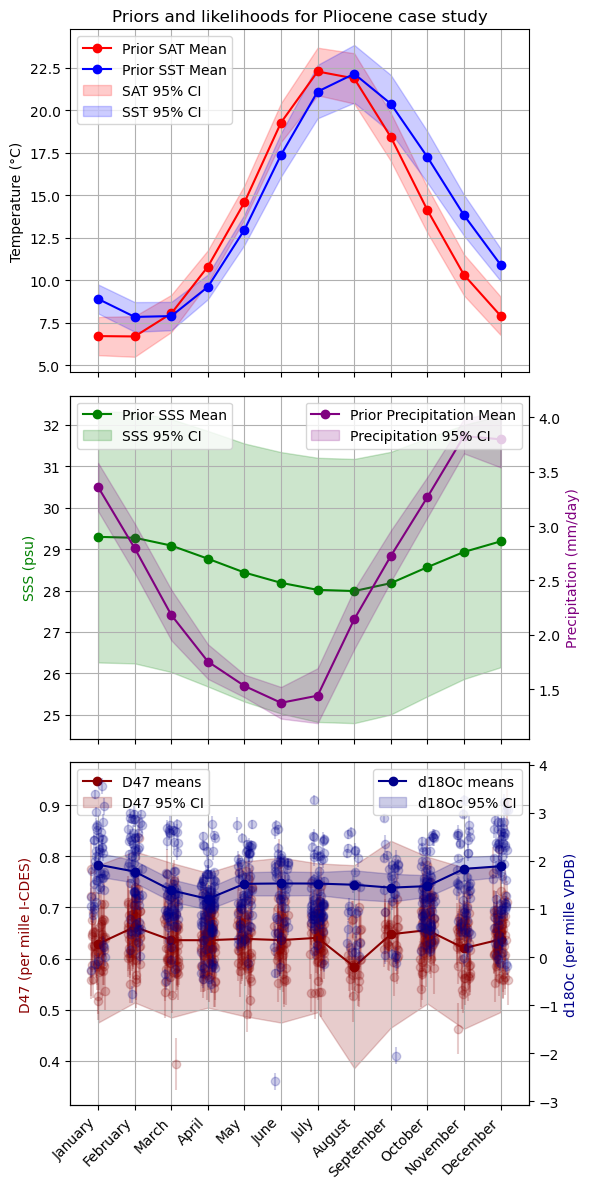

In [ ]:
# Pliocene

# Set dimensions of data
n_models_monthly = len(PlioMIP["modelname"])  # Find the total number of models

# Create list of month names
months = ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']

# Create a monthly scale for the x-axis
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']  # List full month names
months_scale = np.arange(len(months)) + 1  # Create monthly scale

# Create the figure and axes
fig, axes = plt.subplots(3, 1, figsize=(6, 12), sharex=True)

# Panel 1: Plot the prior distribution for SST and SAT
axes[0].plot(months_scale, mu_prior_SAT_monthly, label='Prior SAT Mean', marker='o', color='r')
axes[0].plot(months_scale, mu_prior_SST_monthly, label='Prior SST Mean', marker='o', color='b')

# Add 95% confidence intervals for SAT
axes[0].fill_between(
    months_scale,
    mu_prior_SAT_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SAT_monthly / np.sqrt(n_models_monthly),
    mu_prior_SAT_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SAT_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='r', label='SAT 95% CI'
)

# Add 95% confidence intervals for SST
axes[0].fill_between(
    months_scale,
    mu_prior_SST_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SST_monthly / np.sqrt(n_models_monthly),
    mu_prior_SST_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SST_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='b', label='SST 95% CI'
)

# axes[0].set_title('Prior Mean and 95% Confidence Interval for Monthly SST & SAT Values')
axes[0].set_title('Priors and likelihoods for Pliocene case study')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True)

# Panel 2: Plot the prior distribution for SSS and precipitation
axes[1].plot(months_scale, mu_prior_SSS_monthly, label='Prior SSS Mean', marker='o', color='g')
ax2 = axes[1].twinx()  # Create a secondary y-axis for precipitation
ax2.plot(months_scale, mu_prior_precip_monthly, label='Prior Precipitation Mean', marker='o', color='purple')

# Add 95% confidence intervals for SSS
axes[1].fill_between(
    months_scale,
    mu_prior_SSS_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SSS_monthly / np.sqrt(n_models_monthly),
    mu_prior_SSS_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SSS_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='g', label='SSS 95% CI'
)

# Add 95% confidence intervals for precipitation
ax2.fill_between(
    months_scale,
    mu_prior_precip_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_precip_monthly / np.sqrt(n_models_monthly),
    mu_prior_precip_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_precip_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='purple', label='Precipitation 95% CI'
)

axes[1].set_ylabel('SSS (psu)', color='g')
ax2.set_ylabel('Precipitation (mm/day)', color='purple')
# axes[1].set_title('Prior Mean and 95% Confidence Interval for Monthly SSS & Precipitation Values')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1].grid(True)

# Panel 3: Plot the likelihood distribution for D47 and d18Oc measurements
# Plot individual (non-aggregated) measurements with uncertainties
ax3 = axes[2].twinx()  # secondary y-axis for d18Oc

# Plot D47 likelihood
# Determine the start and end indices for the selected variable to parse information from the likelihood statistics
axes[2].plot(months_scale, mu_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly], marker='o', label='D47 means', color='darkred')
axes[2].fill_between(
    months_scale,
    mu_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly] - 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly]),
    mu_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly] + 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly]),
    color='darkred',
    alpha=0.2,
    label='D47 95% CI'
)
for measurement in PWP_data_dict:
    x_jitter = measurement["month_score"] + np.random.uniform(-0.2, 0.2)
    axes[2].plot(x_jitter, measurement["D47_final"], color="darkred", marker="o", alpha=0.2)
    axes[2].errorbar(x_jitter, measurement["D47_final"], yerr=measurement["D47_sd_ext"], color="darkred", alpha=0.2)

# Plot d18Oc likelihood
# Determine the start and end indices for the selected variable
ax3.plot(months_scale, mu_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly], marker='o', label='d18Oc means', color='darkblue')
ax3.fill_between(
    months_scale,
    mu_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly] - 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly]),
    mu_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly] + 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly]),
    color='darkblue',
    alpha=0.2,
    label='d18Oc 95% CI'
)
for measurement in PWP_data_dict:
    x_jitter = measurement["month_score"] + np.random.uniform(-0.2, 0.2)
    ax3.plot(x_jitter, measurement["Final_d18O"], color="darkblue", marker="o", alpha=0.2)
    ax3.errorbar(x_jitter, measurement["Final_d18O"], yerr=measurement["d18O_sd_ext"], color="darkblue", alpha=0.2)

axes[2].set_ylabel('D47 (per mille I-CDES)', color='darkred')
ax3.set_ylabel('d18Oc (per mille VPDB)', color='darkblue')
axes[2].legend(loc='upper left')
ax3.legend(loc='upper right')
axes[2].grid(True)

# # Update the x-axis with month names
axes[0].set_xticks(months_scale)
axes[0].set_xticklabels(month_names, rotation=45, ha="right")
axes[1].set_xticklabels(month_names, rotation=45, ha="right")
axes[2].set_xticklabels(month_names, rotation=45, ha="right")

# Set tight layout
plt.tight_layout()

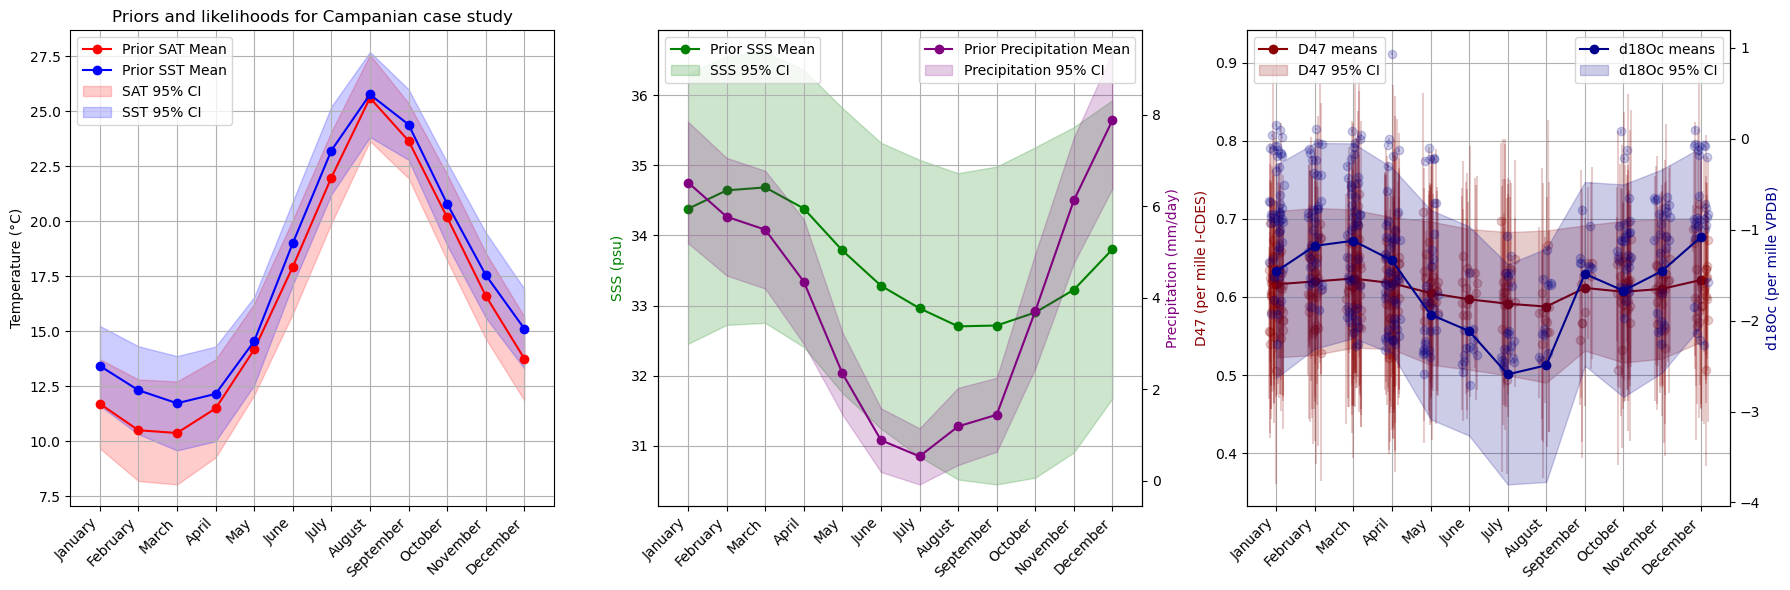

In [ ]:
# Campanian

# Set dimensions of data
n_models_monthly = len(Campanian_models["Cell"])  # Find the total number of models (use monthly data because monthly data has this column duplicated 3 times)

# Create list of month names
months = ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']

# Create a monthly scale for the x-axis
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']  # List full month names
months_scale = np.arange(len(months)) + 1  # Create monthly scale

# Create the figure and axes
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# Panel 1: Plot the prior distribution for SST and SAT
axes[0].plot(months_scale, mu_prior_SAT_monthly, label='Prior SAT Mean', marker='o', color='r')
axes[0].plot(months_scale, mu_prior_SST_monthly, label='Prior SST Mean', marker='o', color='b')

# Add 95% confidence intervals for SAT
axes[0].fill_between(
    months_scale,
    mu_prior_SAT_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SAT_monthly / np.sqrt(n_models_monthly),
    mu_prior_SAT_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SAT_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='r', label='SAT 95% CI'
)

# Add 95% confidence intervals for SST
axes[0].fill_between(
    months_scale,
    mu_prior_SST_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SST_monthly / np.sqrt(n_models_monthly),
    mu_prior_SST_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SST_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='b', label='SST 95% CI'
)

# axes[0].set_title('Prior Mean and 95% Confidence Interval for Monthly SST & SAT Values')
axes[0].set_title('Priors and likelihoods for Campanian case study')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True)

# Panel 2: Plot the prior distribution for SSS and precipitation
axes[1].plot(months_scale, mu_prior_SSS_monthly, label='Prior SSS Mean', marker='o', color='g')
ax2 = axes[1].twinx()  # Create a secondary y-axis for precipitation
ax2.plot(months_scale, mu_prior_precip_monthly, label='Prior Precipitation Mean', marker='o', color='purple')

# Add 95% confidence intervals for SSS
axes[1].fill_between(
    months_scale,
    mu_prior_SSS_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SSS_monthly / np.sqrt(n_models_monthly),
    mu_prior_SSS_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SSS_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='g', label='SSS 95% CI'
)

# Add 95% confidence intervals for precipitation
ax2.fill_between(
    months_scale,
    mu_prior_precip_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_precip_monthly / np.sqrt(n_models_monthly),
    mu_prior_precip_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_precip_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='purple', label='Precipitation 95% CI'
)

axes[1].set_ylabel('SSS (psu)', color='g')
ax2.set_ylabel('Precipitation (mm/day)', color='purple')
# axes[1].set_title('Prior Mean and 95% Confidence Interval for Monthly SSS & Precipitation Values')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1].grid(True)

# Panel 3: Plot the likelihood distribution for D47 and d18Oc measurements
# Plot individual (non-aggregated) measurements with uncertainties
ax3 = axes[2].twinx()  # secondary y-axis for d18Oc

# Plot D47 likelihood
# Determine the start and end indices for the selected variable to parse information from the likelihood statistics
axes[2].plot(months_scale, mu_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly], marker='o', label='D47 means', color='darkred')
axes[2].fill_between(
    months_scale,
    mu_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly] - 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly]),
    mu_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly] + 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly]),
    color='darkred',
    alpha=0.2,
    label='D47 95% CI'
)
for measurement in Campanian_data_dict:
    x_jitter = measurement["month_score"] + 1 + np.random.uniform(-0.2, 0.2)
    axes[2].plot(x_jitter, measurement["D47"], color="darkred", marker="o", alpha=0.2)
    axes[2].errorbar(x_jitter, measurement["D47"], yerr=measurement["D47_SD"], color="darkred", alpha=0.2)

# Plot d18Oc likelihood
# Determine the start and end indices for the selected variable
ax3.plot(months_scale, mu_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly], marker='o', label='d18Oc means', color='darkblue')
ax3.fill_between(
    months_scale,
    mu_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly] - 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly]),
    mu_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly] + 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly]),
    color='darkblue',
    alpha=0.2,
    label='d18Oc 95% CI'
)
for measurement in Campanian_data_dict:
    x_jitter = measurement["month_score"] + 1 + np.random.uniform(-0.2, 0.2)
    ax3.plot(x_jitter, measurement["d18Occ"], color="darkblue", marker="o", alpha=0.2)
    ax3.errorbar(x_jitter, measurement["d18Occ"], yerr=measurement["d18O_SD"], color="darkblue", alpha=0.2)

axes[2].set_ylabel('D47 (per mille I-CDES)', color='darkred')
ax3.set_ylabel('d18Oc (per mille VPDB)', color='darkblue')
axes[2].legend(loc='upper left')
ax3.legend(loc='upper right')
axes[2].grid(True)

# # Update the x-axis with month names
axes[0].set_xticks(months_scale)
axes[0].set_xticklabels(month_names, rotation=45, ha="right")
axes[1].set_xticklabels(month_names, rotation=45, ha="right")
axes[2].set_xticklabels(month_names, rotation=45, ha="right")

# Set tight layout
plt.tight_layout()

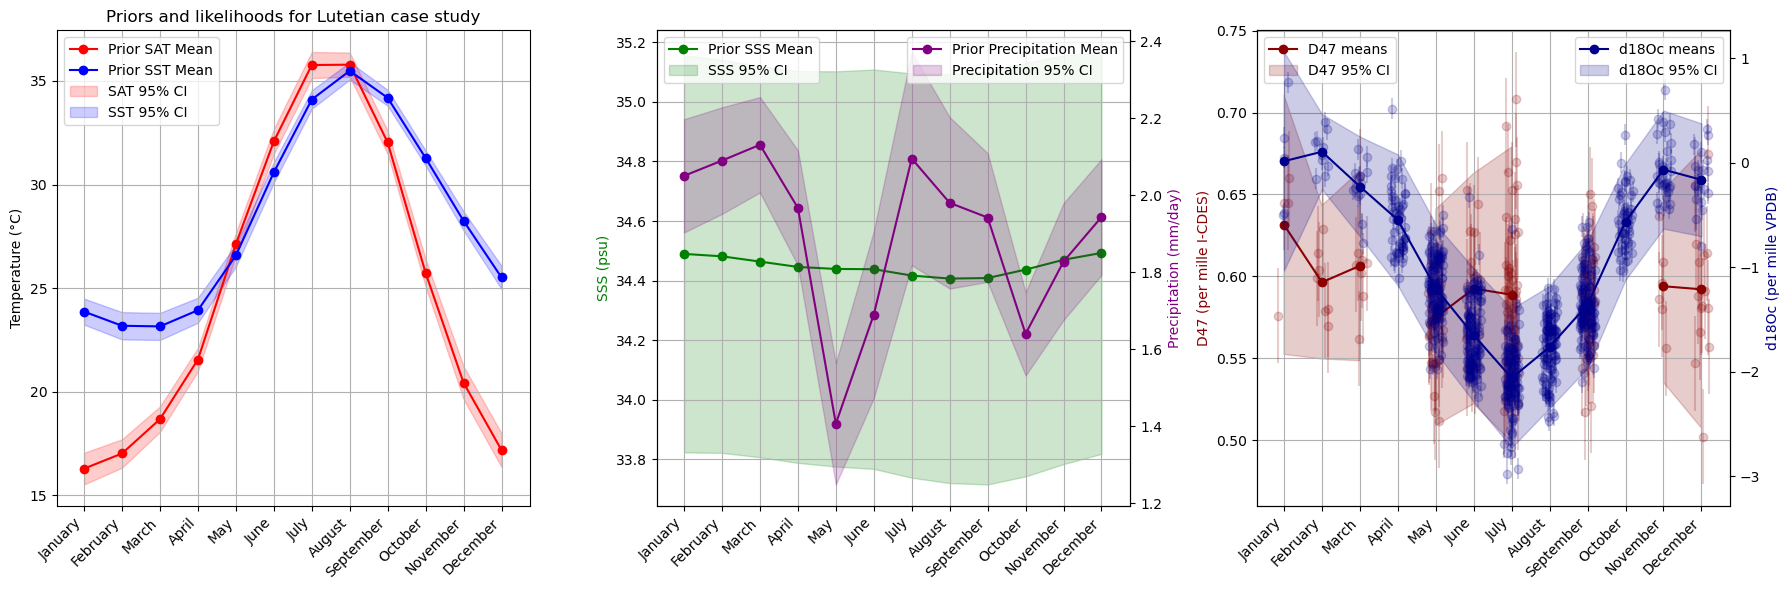

In [ ]:
# Lutetian

# Set dimensions of data
n_models_monthly = len(Lutetian_models["Cell"])  # Find the total number of models

# Create list of month names
months = ['ja', 'fb', 'mr', 'ar', 'my', 'jn', 'jl', 'ag', 'sp', 'ot', 'nv', 'dc']

# Create a monthly scale for the x-axis
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']  # List full month names
months_scale = np.arange(len(months)) + 1  # Create monthly scale

# Create the figure and axes
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# Panel 1: Plot the prior distribution for SST and SAT
axes[0].plot(months_scale, mu_prior_SAT_monthly, label='Prior SAT Mean', marker='o', color='r')
axes[0].plot(months_scale, mu_prior_SST_monthly, label='Prior SST Mean', marker='o', color='b')

# Add 95% confidence intervals for SAT
axes[0].fill_between(
    months_scale,
    mu_prior_SAT_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SAT_monthly / np.sqrt(n_models_monthly),
    mu_prior_SAT_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SAT_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='r', label='SAT 95% CI'
)

# Add 95% confidence intervals for SST
axes[0].fill_between(
    months_scale,
    mu_prior_SST_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SST_monthly / np.sqrt(n_models_monthly),
    mu_prior_SST_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SST_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='b', label='SST 95% CI'
)

# axes[0].set_title('Prior Mean and 95% Confidence Interval for Monthly SST & SAT Values')
axes[0].set_title('Priors and likelihoods for Lutetian case study')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True)

# Panel 2: Plot the prior distribution for SSS and precipitation
axes[1].plot(months_scale, mu_prior_SSS_monthly, label='Prior SSS Mean', marker='o', color='g')
ax2 = axes[1].twinx()  # Create a secondary y-axis for precipitation
ax2.plot(months_scale, mu_prior_precip_monthly, label='Prior Precipitation Mean', marker='o', color='purple')

# Add 95% confidence intervals for SSS
axes[1].fill_between(
    months_scale,
    mu_prior_SSS_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SSS_monthly / np.sqrt(n_models_monthly),
    mu_prior_SSS_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_SSS_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='g', label='SSS 95% CI'
)

# Add 95% confidence intervals for precipitation
ax2.fill_between(
    months_scale,
    mu_prior_precip_monthly - stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_precip_monthly / np.sqrt(n_models_monthly),
    mu_prior_precip_monthly + stats.t.ppf(1 - 0.025, n_models_monthly) * std_prior_precip_monthly / np.sqrt(n_models_monthly),
    alpha=0.2, color='purple', label='Precipitation 95% CI'
)

axes[1].set_ylabel('SSS (psu)', color='g')
ax2.set_ylabel('Precipitation (mm/day)', color='purple')
# axes[1].set_title('Prior Mean and 95% Confidence Interval for Monthly SSS & Precipitation Values')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1].grid(True)

# Panel 3: Plot the likelihood distribution for D47 and d18Oc measurements
# Plot individual (non-aggregated) measurements with uncertainties
ax3 = axes[2].twinx()  # secondary y-axis for d18Oc

# Plot D47 likelihood
# Determine the start and end indices for the selected variable to parse information from the likelihood statistics
axes[2].plot(months_scale, mu_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly], marker='o', label='D47 means', color='darkred')
axes[2].fill_between(
    months_scale,
    mu_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly] - 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly]),
    mu_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly] + 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_D47_monthly:var_end_D47_monthly]),
    color='darkred',
    alpha=0.2,
    label='D47 95% CI'
)
for measurement in Lutetian_data_dict:
    x_jitter = measurement["month_score"] + 1 + np.random.uniform(-0.2, 0.2)
    axes[2].plot(x_jitter, measurement["D47_final"], color="darkred", marker="o", alpha=0.2)
    axes[2].errorbar(x_jitter, measurement["D47_final"], yerr=measurement["D47_SD"], color="darkred", alpha=0.2)

# Plot d18Oc likelihood
# Determine the start and end indices for the selected variable
ax3.plot(months_scale, mu_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly], marker='o', label='d18Oc means', color='darkblue')
ax3.fill_between(
    months_scale,
    mu_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly] - 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly]),
    mu_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly] + 1.96 * np.sqrt(std_likelihood_monthly_aggregated[var_start_d18Oc_monthly:var_end_d18Oc_monthly]),
    color='darkblue',
    alpha=0.2,
    label='d18Oc 95% CI'
)
for measurement in Lutetian_data_dict:
    x_jitter = measurement["month_score"] + 1 + np.random.uniform(-0.2, 0.2)
    ax3.plot(x_jitter, measurement["d18O"], color="darkblue", marker="o", alpha=0.2)
    ax3.errorbar(x_jitter, measurement["d18O"], yerr=measurement["d18O_SD"], color="darkblue", alpha=0.2)

axes[2].set_ylabel('D47 (per mille I-CDES)', color='darkred')
ax3.set_ylabel('d18Oc (per mille VPDB)', color='darkblue')
axes[2].legend(loc='upper left')
ax3.legend(loc='upper right')
axes[2].grid(True)

# # Update the x-axis with month names
axes[0].set_xticks(months_scale)
axes[0].set_xticklabels(month_names, rotation=45, ha="right")
axes[1].set_xticklabels(month_names, rotation=45, ha="right")
axes[2].set_xticklabels(month_names, rotation=45, ha="right")

# Set tight layout
plt.tight_layout()